In [ ]:
# 데이터 셋 다운로드
!wget https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip
!unzip human+activity+recognition+using+smartphones.zip

In [ ]:
# 압축풀기
!unzip "UCI HAR Dataset.zip"


In [ ]:
# 이동
!mv "human_activity/UCI HAR Dataset" "UCI HAR Dataset"

In [ ]:
# 복사
!cp "UCI HAR Dataset/features.txt" "UCI HAR Dataset/train/features.txt"

In [ ]:
import os
os.listdir()

['.config',
 '__MACOSX',
 'UCI HAR Dataset.zip',
 'UCI HAR Dataset',
 'human+activity+recognition+using+smartphones.zip',
 'UCI HAR Dataset.names',
 '.ipynb_checkpoints',
 'human_activity',
 'sample_data']

In [ ]:
# adaboost
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# 데이터셋을 구하는 함수 설정
def get_human_dataset():
  # 각 데이터 파일들은 공백으로 분리되어 있으므로 read_csv에서 공백문자를 sep 으로  할당
  feature_name_df = pd.read_csv('UCI HAR Dataset/train/features.txt', sep = '\s+',
                                header = None, names = ['column_index', 'column_name'])
  # 데이터프레임에 피쳐명을 컬럼으로 부여하기 위해 리스트 객체로 다시 반환
  feature_name = feature_name_df.iloc[:, 1].values.tolist()

  # 학습 피처 데이터세트와 테스트 피쳐 데이터를 데이터 프레임으로 로딩
  # 컬럼명은 feature_name 적용
  X_train = pd.read_csv('UCI HAR Dataset/train/X_train.txt' , sep = '\s+', names = feature_name)
  X_test = pd.read_csv('UCI HAR Dataset/test/X_test.txt', sep = '\s+', names = feature_name)

  # 학습 레이블과 테스트 레이블 데이터를 데이터 프레임으로 로딩, 컬럼명은 action 으로 부여
  y_train = pd.read_csv('UCI HAR Dataset/train/y_train.txt', sep = '\s+', names = ['action'])
  y_test = pd.read_csv('UCI HAR Dataset/test/y_test.txt', sep = '\s+', names =['action'])

  # 로드된 학습 / 테스트용 데이터프레임을 모두 반환
  return X_train, X_test, y_train, y_test

# 학습/테스트용 데이터 프레임 반환
X_train, X_test, y_train, y_test = get_human_dataset()


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

clf = AdaBoostClassifier(n_estimators=30,
                         random_state= 10,
                         learning_rate=0.1)
clf.fit(X_train, y_train)
pred = clf.predict(X_test)
print('Ada boost 정확도 : {:.4f}'.format(accuracy_score(y_test, pred)))
# Ada boost 정확도 : 0.5310 수치가 다름 / 경로를 움직이면서 문제가 생긴건지, 버젼 이슈인지 확인 필요

Ada boost 정확도 : 0.7720


In [ ]:
!mkdir -p human_activity/train human_activity/test
!cp "UCI HAR Dataset/features.txt" human_activity/features.txt
!cp "UCI HAR Dataset/train/X_train.txt" human_activity/train/X_train.txt
!cp "UCI HAR Dataset/train/y_train.txt" human_activity/train/y_train.txt
!cp "UCI HAR Dataset/test/X_test.txt" human_activity/test/X_test.txt
!cp "UCI HAR Dataset/test/y_test.txt" human_activity/test/y_test.txt

In [ ]:
# 현재 버전 1.6.1
import sklearn
print(sklearn.__version__)
print(X_train.shape, X_test.shape)
print(y_train['action'].value_counts().sort_index())

1.5.2
(7352, 561) (2947, 561)
action
1    1226
2    1073
3     986
4    1286
5    1374
6    1407
Name: count, dtype: int64


In [ ]:
# 출력 결과 다름 버젼 이슈로 다운그레이드 진행
!pip -q install scikit-learn==1.5.2

In [ ]:
# 재시작
import os, sys
os.kill(os.getpid(), 9)

In [ ]:
# 다운그레이드 버전 재확인 1.5.2
import sklearn
print(sklearn.__version__)

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

clf = AdaBoostClassifier(n_estimators=30,
                         random_state= 10,
                         learning_rate=0.1)
clf.fit(X_train, y_train)
pred = clf.predict(X_test)
print('Ada boost 정확도 : {:.4f}'.format(accuracy_score(y_test, pred)))

Ada boost 정확도 : 0.7720


# ADA 알고리즘

틀린 데이터를 다시 전체 학습하는 것이 아니라,


이전 모델이 틀린 데이터의 중요도(weight)를 높여


다음 모델이 그 데이터를 더 많이 보도록 학습 방식을 조정하는 알고리즘이다.

In [ ]:
# Gradient Boosting Classifier 불러오기
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
import time

# GBM 수행시간 측정을 위함. 시작시간 설정
start_time = time.time()

# 예시 데이터셋 불러오기
gb_clf = GradientBoostingClassifier(random_state = 0, n_estimators=50)
gb_clf.fit(X_train, y_train.values.ravel())
gb_pred = gb_clf.predict(X_test)
gb_accuracy = accuracy_score(y_test.values.ravel(), gb_pred)
print('GBM 정확도 : {:.4f}'.format(gb_accuracy))
print('GBM 수행 시간 : {:.1f}초'.format(time.time() - start_time))

GBM 정확도 : 0.9311
GBM 수행 시간 : 681.0초


In [ ]:
import os, platform
print(platform.platform())
print("CPU cores:", os.cpu_count())

Linux-6.6.113+-x86_64-with-glibc2.35
CPU cores: 2


In [ ]:
X_train.dtypes.value_counts()

,count
float64,561


In [ ]:
# Gradient Boosting Classifier 불러오기
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
import time

# GBM 수행시간 측정을 위함. 시작시간 설정
start_time = time.time()

# 예시 데이터셋 불러오기
gb_clf = GradientBoostingClassifier(random_state = 0, n_estimators=100)
gb_clf.fit(X_train, y_train.values.ravel())
gb_pred = gb_clf.predict(X_test)
gb_accuracy = accuracy_score(y_test.values.ravel(), gb_pred)
print('GBM 정확도 : {:.4f}'.format(gb_accuracy))
print('GBM 수행 시간 : {:.1f}초'.format(time.time() - start_time))

GBM 정확도 : 0.9386
GBM 수행 시간 : 1373.3초


# Gradient Boosting

Gradient Boosting은 AdaBoost보다 높은 정확도를 보였지만, CPU 환경에서는 학습 시간이 매우 오래 소요되었다.

실행이 정상적으로 되고 있는지 의문이 들 정도로 오랜 시간이 걸렸고, 여러 번 실행을 시도한 끝에 다른 작업을 하며 기다린 뒤 결과를 확인할 수 있었다.

이번 실습은 무료 Google Colab 환경(CPU 2코어)에서 진행했는데, 모델 학습 과정에서 왜 고성능 연산 환경이 필요한지 직접 체감할 수 있었다.

특히 Gradient Boosting은 이전 모델의 오차를 순차적으로 보정하며 트리를 계속 추가하는 방식이기 때문에, 병렬 처리의 이점이 크지 않아 CPU 성능에 크게 영향을 받는다는 점을 경험적으로 이해하게 되었다.

- AdaBoost → 틀린 데이터를 더 중요하게 다시 학습
- Gradient Boosting → 모델의 오차 방향을 직접 학습하며 성능 개선

Ada boost 정확도 : 0.7720

GBM 정확도 : 0.9386

In [ ]:
import xgboost
print(xgboost.__version__)

3.2.0


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import time

y_tr = y_train.values.ravel() - 1
y_te = y_test.values.ravel() - 1

start = time.time()
xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.1,
    max_depth=3,
    objective="multi:softprob",
    num_class=6,
    eval_metric="mlogloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=0
)
xgb.fit(X_train, y_tr)
pred = xgb.predict(X_test)
print("XGBoost 정확도:", accuracy_score(y_te, pred))
print("수행시간:", round(time.time()-start, 1), "초")

XGBoost 정확도: 0.9507974211062097
수행시간: 95.8 초


In [ ]:
# 이진분류 데이터 로드(0,1) , 위스콘신주
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

In [ ]:
# train / test 분리
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# X_train 컬럼명 변경
X_train_short = X_train.copy()
X_train_short.columns = [f"f{i}" for i in range(X_train_short.shape[1])]

X_test_short = X_test.copy()
X_test_short.columns = [f"f{i}" for i in range(X_test_short.shape[1])]

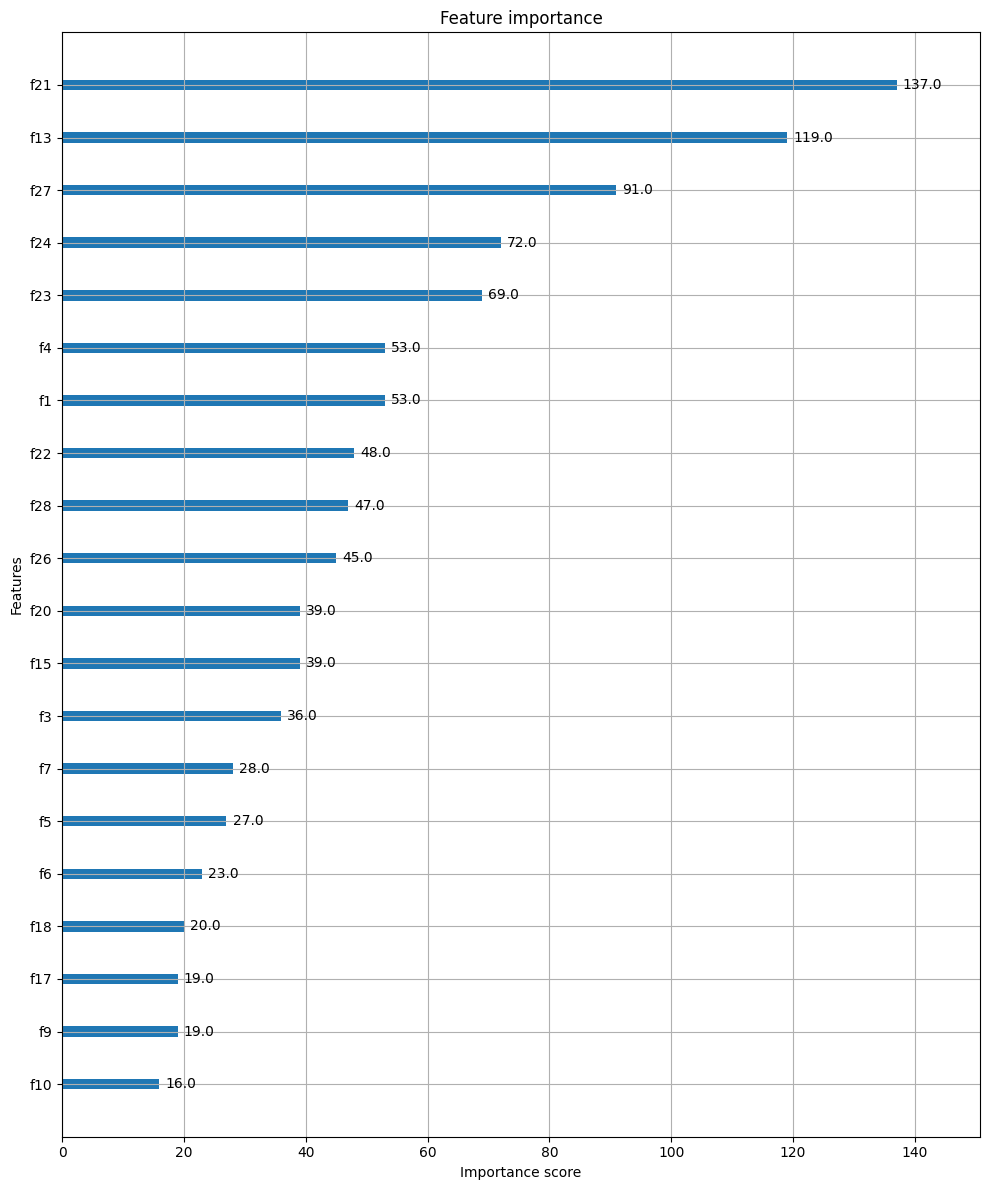

In [ ]:
# XG boost 학습
from xgboost import XGBClassifier, plot_importance
import matplotlib.pyplot as plt

xgb_bc = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    eval_metric="logloss",
    tree_method="hist",
    random_state=42
)

xgb_bc.fit(X_train_short, y_train)

fig, ax = plt.subplots(figsize=(10, 12))
plot_importance(
    xgb_bc,
    ax=ax,
    max_num_features=20,      # 상위 20개만
    importance_type="weight"
)
plt.tight_layout()
plt.show()

## XGBoost Feature Importance

모델은 입력 feature들을 기준으로 데이터를 분할하며 예측을 수행한다.  
Feature Importance 그래프는 각 feature가 모델 학습 과정에서 얼마나 자주 사용되었는지를 나타낸다.

막대의 길이가 길수록 해당 feature가 의사결정 트리의 분할 기준으로 많이 사용되었음을 의미하며,
이는 악성/양성 분류 과정에서 높은 영향력을 가진 변수임을 보여준다.

즉, 모델이 어떤 특징을 중요하게 판단했는지 해석할 수 있는 지표이다

In [25]:
from lightgbm import LGBMClassifier, early_stopping, log_evaluation # LightGBM 불러오기

import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, roc_auc_score
from sklearn.metrics import confusion_matrix

dataset = load_breast_cancer()
ftr = dataset.data
target = dataset.target

feature_names = dataset.feature_names  # 피처 이름 가져오기

# X does not have valid feature names 경고문구
# split 전에 DataFrame으로 변환
# 앞전에 실습을 DataFrame 으로 했기때문에 numpy → DataFrame 변환하여 진행
ftr = pd.DataFrame(ftr, columns=feature_names)




# 예제 데이터 세트 중 80%를 학습, 20%를 테스트 데이터셋으로 분할
X_train, X_test, y_train, y_test = train_test_split(ftr, target, test_size = 0.2, random_state = 156)

# 트리개수는 400개로 지정
lgbm_wrapper = LGBMClassifier(n_estimators=400, random_state = 156)

# LGBM도 XGBoost 처럼 early stopping 가능
evals = [(X_test, y_test)]
lgbm_wrapper.fit(X_train, y_train, eval_set=evals, eval_metric = 'logloss',
                 callbacks = [early_stopping(stopping_rounds = 100),
                              log_evaluation(10)]) # 10 iteration마다 로그 출력 (verbose 대체)
# ightGBM 최신 버전에서 early_stopping_rounds 삭제됨

preds = lgbm_wrapper.predict(X_test)

# =============로그분석=============================================
# 전체 데이터 455개
# [LightGBM] [Info] Number of positive: 280, number of negative: 175

# 사용한 피쳐는 30개
# [LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30

# 이미 45번째 에서 최적의 성능을 찾았고, 중단했다.
# Early stopping, best iteration is:
# [45]	valid_0's binary_logloss: 0.122818  ←검증손실(loss)

# [LightGBM] [Warning] No further splits with positive gain, best gain: -inf
# 더 분리 할 수 있는 데이터가 없음

# 50 번째 부터 악화가 시작되었다. 이후로 계속 loss값이 올라가는것을 확인.
# [50]	valid_0's binary_logloss: 0.127004
# =================================================================

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 280, number of negative: 175
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000187 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4542
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.615385 -> initscore=0.470004
[LightGBM] [Info] Start training from score 0.470004
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

In [32]:
# 혼동행렬 , 정확도, 정밀도, 재현율, F1 , AUC
def get_clf_eval(y_test, y_pred):
    confusion = confusion_matrix(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    F1 = f1_score(y_test, y_pred)
    AUC = roc_auc_score(y_test, y_pred)

    print('오차행렬 :\n', confusion)
    print('\n정확도 : {:.4f}'.format(accuracy))
    print('정밀도 : {:.4f}'.format(precision))
    print('재현율 : {:.4f}'.format(recall))
    print('F1 : {:.4f}'.format(F1))
    print('AUC : {:.4f}'.format(AUC))



# 실습 → predict 사용 (0/1 그대로 AUC 계산, 흐름 이해용)
get_clf_eval(y_test, preds)

print("="*20)
# 실무 → predict_proba 사용 (확률값으로 AUC 계산, 더 정확)
pred_proba = lgbm_wrapper.predict_proba(X_test)[:, 1]

# AUC만 따로 출력
print('AUC (proba) : {:.4f}'.format(roc_auc_score(y_test, pred_proba)))

오차행렬 :
 [[33  4]
 [ 1 76]]

정확도 : 0.9561
정밀도 : 0.9500
재현율 : 0.9870
F1 : 0.9682
AUC : 0.9395
AUC (proba) : 0.9905
